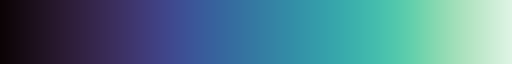

In [60]:
import numpy as np
from scipy.spatial import Delaunay
import pandas as pd
from itertools import combinations
import os
from scipy.stats import ecdf
from sklearn.decomposition import PCA
from astropy.table import Table as t

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.tri as mtri
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})
# plt.style.use('default')
cmap = sns.color_palette('mako', as_cmap=True)
cmap

In [61]:
base_url = './data/coord/'

In [62]:
def compute_r(df):
    coords = df[['X', 'Y', 'Z']].values
    is_data = ~df['RAN'].values

    tri = Delaunay(coords)
    neighbors = {i: set() for i in range(len(coords))}
    for simplex in tri.simplices:
        for i, j in combinations(simplex, 2):
            neighbors[i].add(j)
            neighbors[j].add(i)

    r = np.zeros(len(coords), dtype=float)
    for i, nbrs in neighbors.items():
        n_data = int(np.sum(is_data[list(nbrs)]))
        n_rand = len(nbrs) - n_data
        if (n_data + n_rand) > 0:
            r[i] = (n_data - n_rand) / (n_data + n_rand)
        else:
            raise ValueError(f'No neighbors for point {i} in the triangulation.')

    out = df.copy()
    out['r'] = r
    return out

def classify_r(df):
    r = df['r'].values
    conds = [(r >= -1.0) & (r <= -0.9),
             (r > -0.9) & (r <= 0.0),
             (r > 0.0) & (r <= 0.9),
             (r > 0.9) & (r <= 1.0),]
    choices = ['void', 'sheet', 'filament', 'knot']
    df = df.copy()
    df['TYPE'] = np.select(conds, choices, default='error')
    return df

def astra(data, rand):
    data['RAN'] = False
    rand['RAN'] = True
    df = pd.concat([data, rand], ignore_index=True)

    df_r = compute_r(df)
    df_typed = classify_r(df_r)
    coords2d = df_typed[['X','Y','Z']].values
    tri = Delaunay(coords2d)

    is_real = ~df_typed['RAN'].values
    return df_typed, coords2d, tri, is_real

### Table

In [ ]:
dfs = []
for r_id in range(20):
    data = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_data.ecsv',
                       comment='#', sep=r'\s+', engine='python')
    rand = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_rand.ecsv',
                       comment='#', sep=r'\s+', engine='python')[:data.shape[0]]

    df, _, _, _ = astra(data, rand)
    ct = df.groupby(['RAN','TYPE']).size().rename('count').reset_index()
    ct['total'] = ct.groupby('RAN')['count'].transform('sum')
    ct['frac'] = ct['count'] / ct['total']
    # err = sqrt(p(1−p)/N)
    ct['error'] = np.sqrt(ct['frac'] * (1-ct['frac']) / ct['total'])

    ct['perc'] = ct['frac'] * 100
    ct['perc_error'] = ct['error'] * 100

    table = ct.pivot(index='RAN', columns='TYPE', values=['perc','perc_error']).fillna(0)

    def fmt(row, env):
        m = row[('perc', env)]
        e = row[('perc_error', env)]
        return f"{m:.2f} ± {e:.2f}%"

    final = pd.DataFrame(index=table.index)
    for env in ['void','sheet','filament','knot']:
        final[env.capitalize()] = table.apply(lambda r: fmt(r, env), axis=1)

    final = final.rename(index={0:'Data', 1:'Random'})
    final['Rosette'] = r_id

    dfs.append(final)

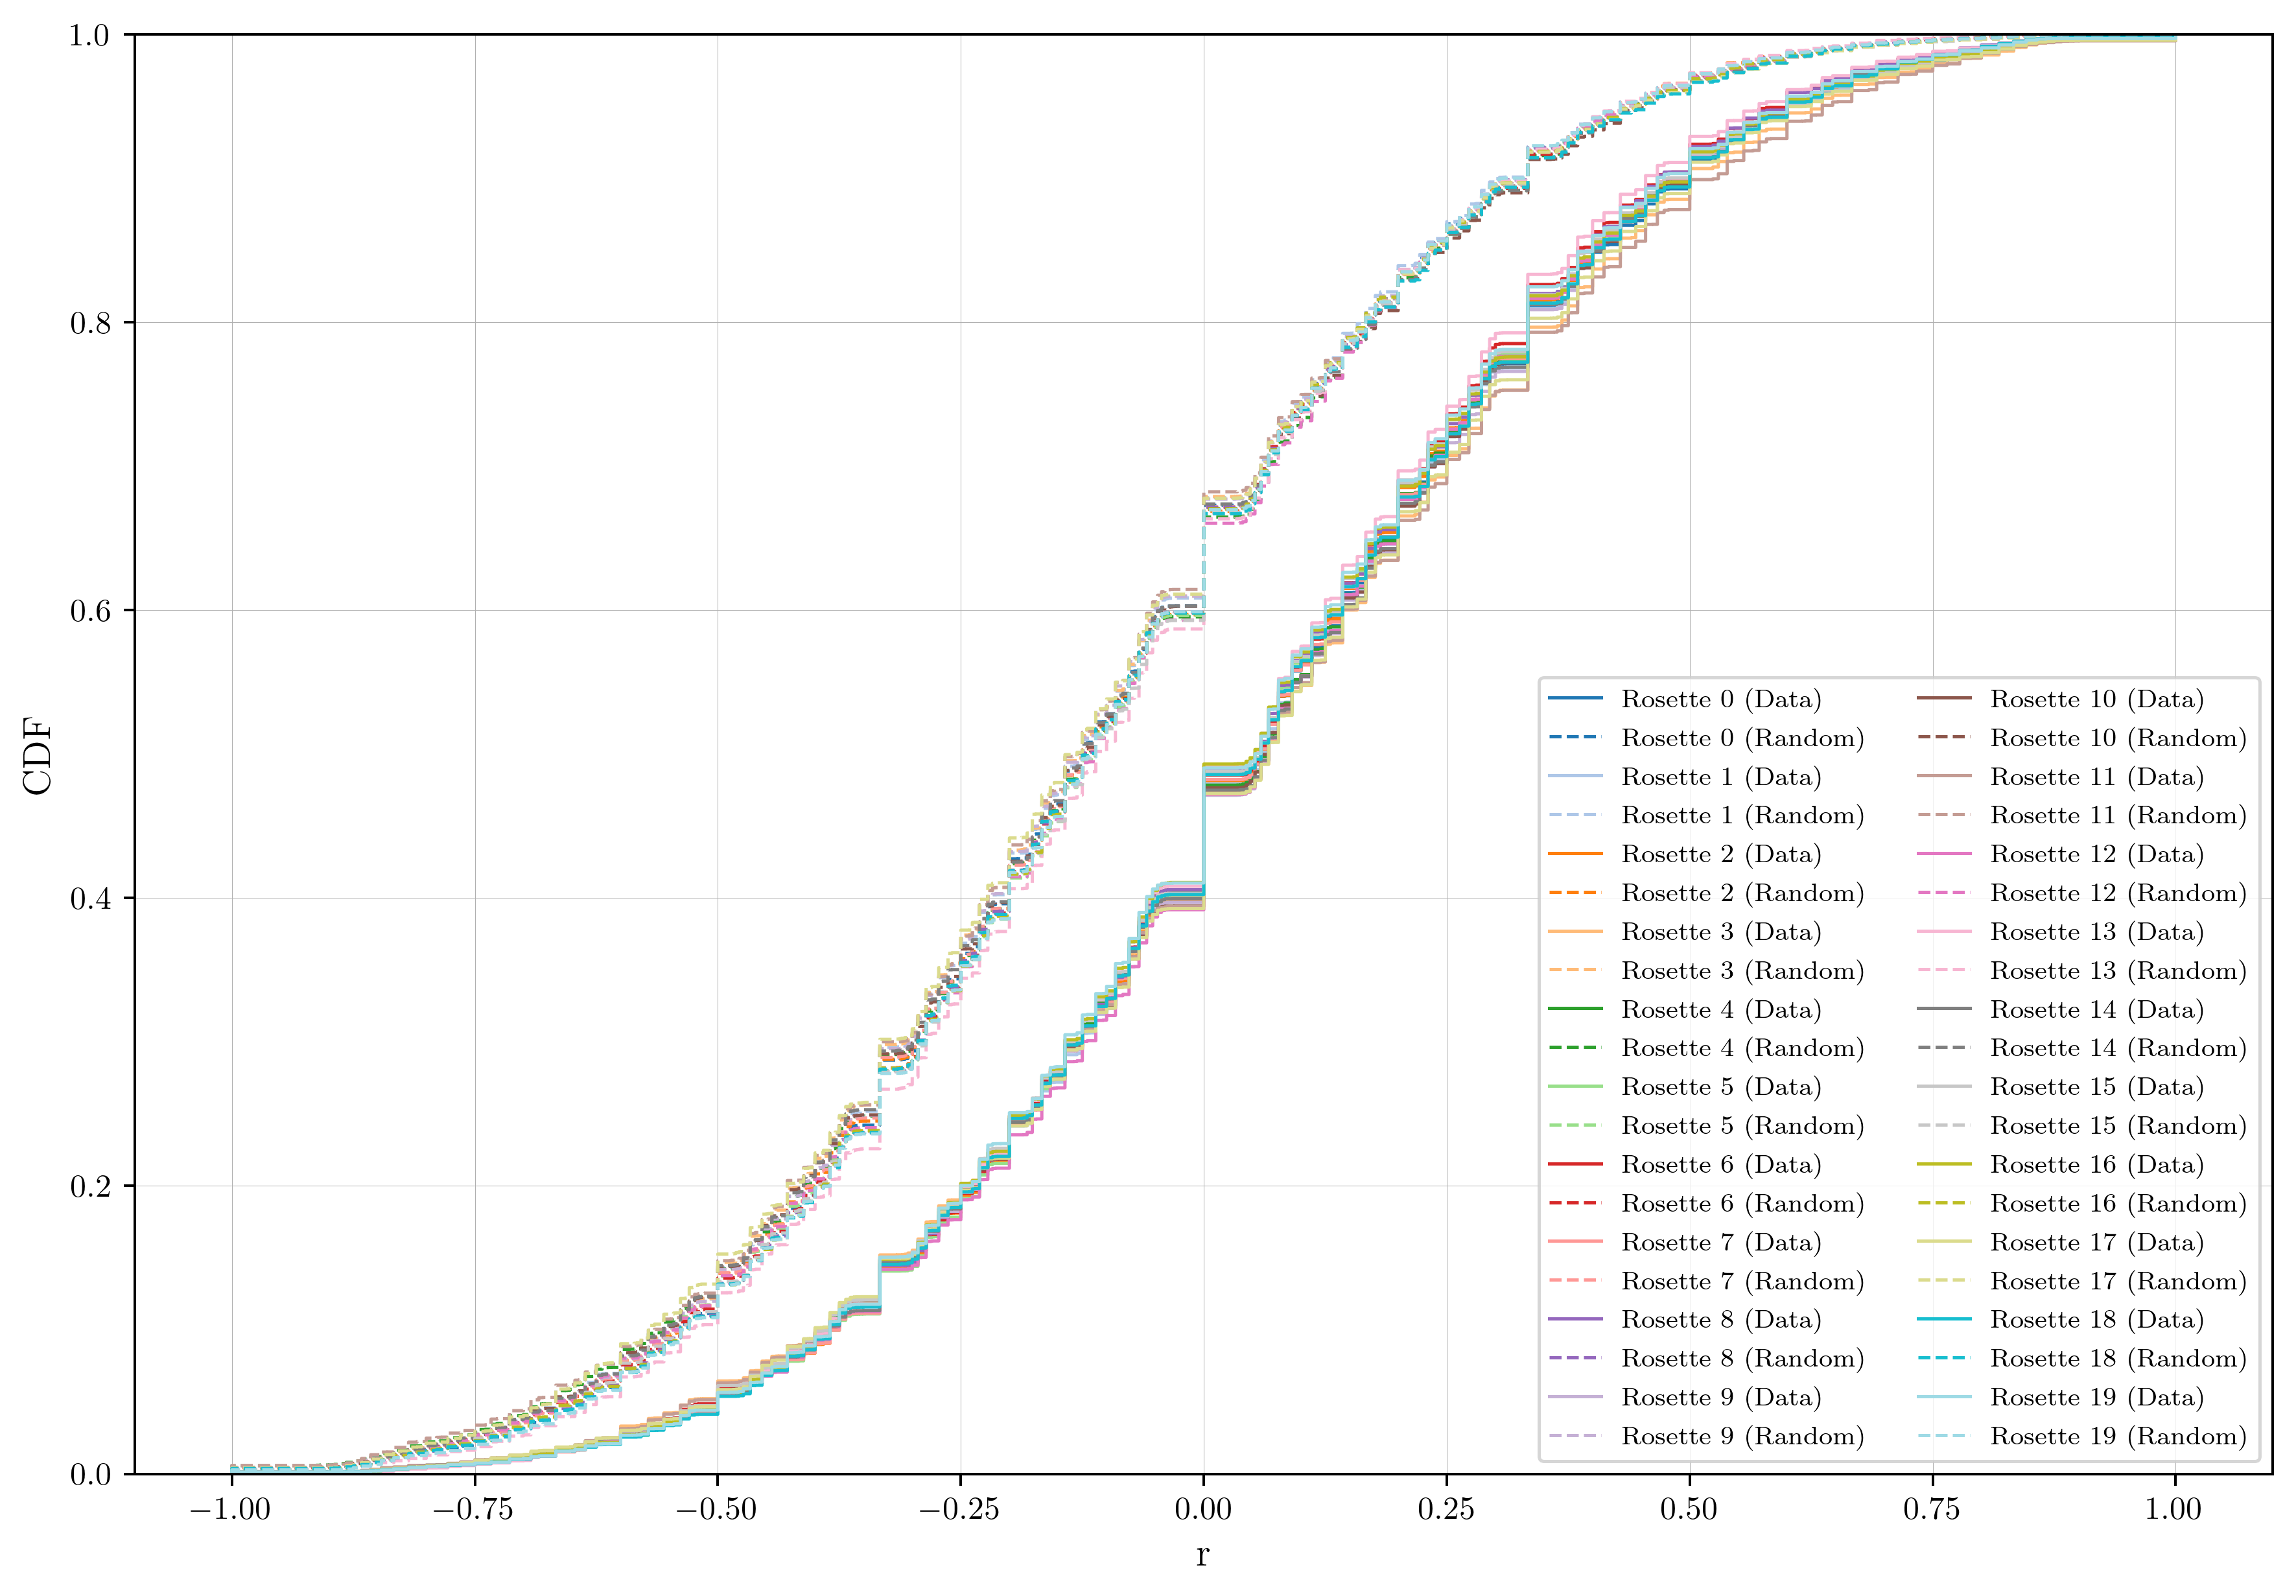

In [57]:
fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.get_cmap('tab20')
plt.grid(linewidth=0.2, zorder=0)

for r_id in range(20):
    data = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_data.ecsv', comment='#',
                   sep=r'\s+', engine='python')
    rand = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_rand.ecsv', comment='#',
                        sep=r'\s+', engine='python')
    indices = np.random.choice(len(rand), size=len(data), replace=False)
    subset_rand = rand.iloc[indices].reset_index(drop=True)

    df, _, _, _ = astra(data, subset_rand)
    sns.ecdfplot(df[df['RAN'] == False]['r'], label=f'Rosette {r_id} (Data)',
                 ls='-', color=cmap(r_id), lw=1.)
    sns.ecdfplot(df[df['RAN'] == True]['r'], color=cmap(r_id), ls='--', lw=1.,
                 label=f'Rosette {r_id} (Random)',)

ax.set_xlabel('r')
ax.set_ylabel('CDF')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Histogram

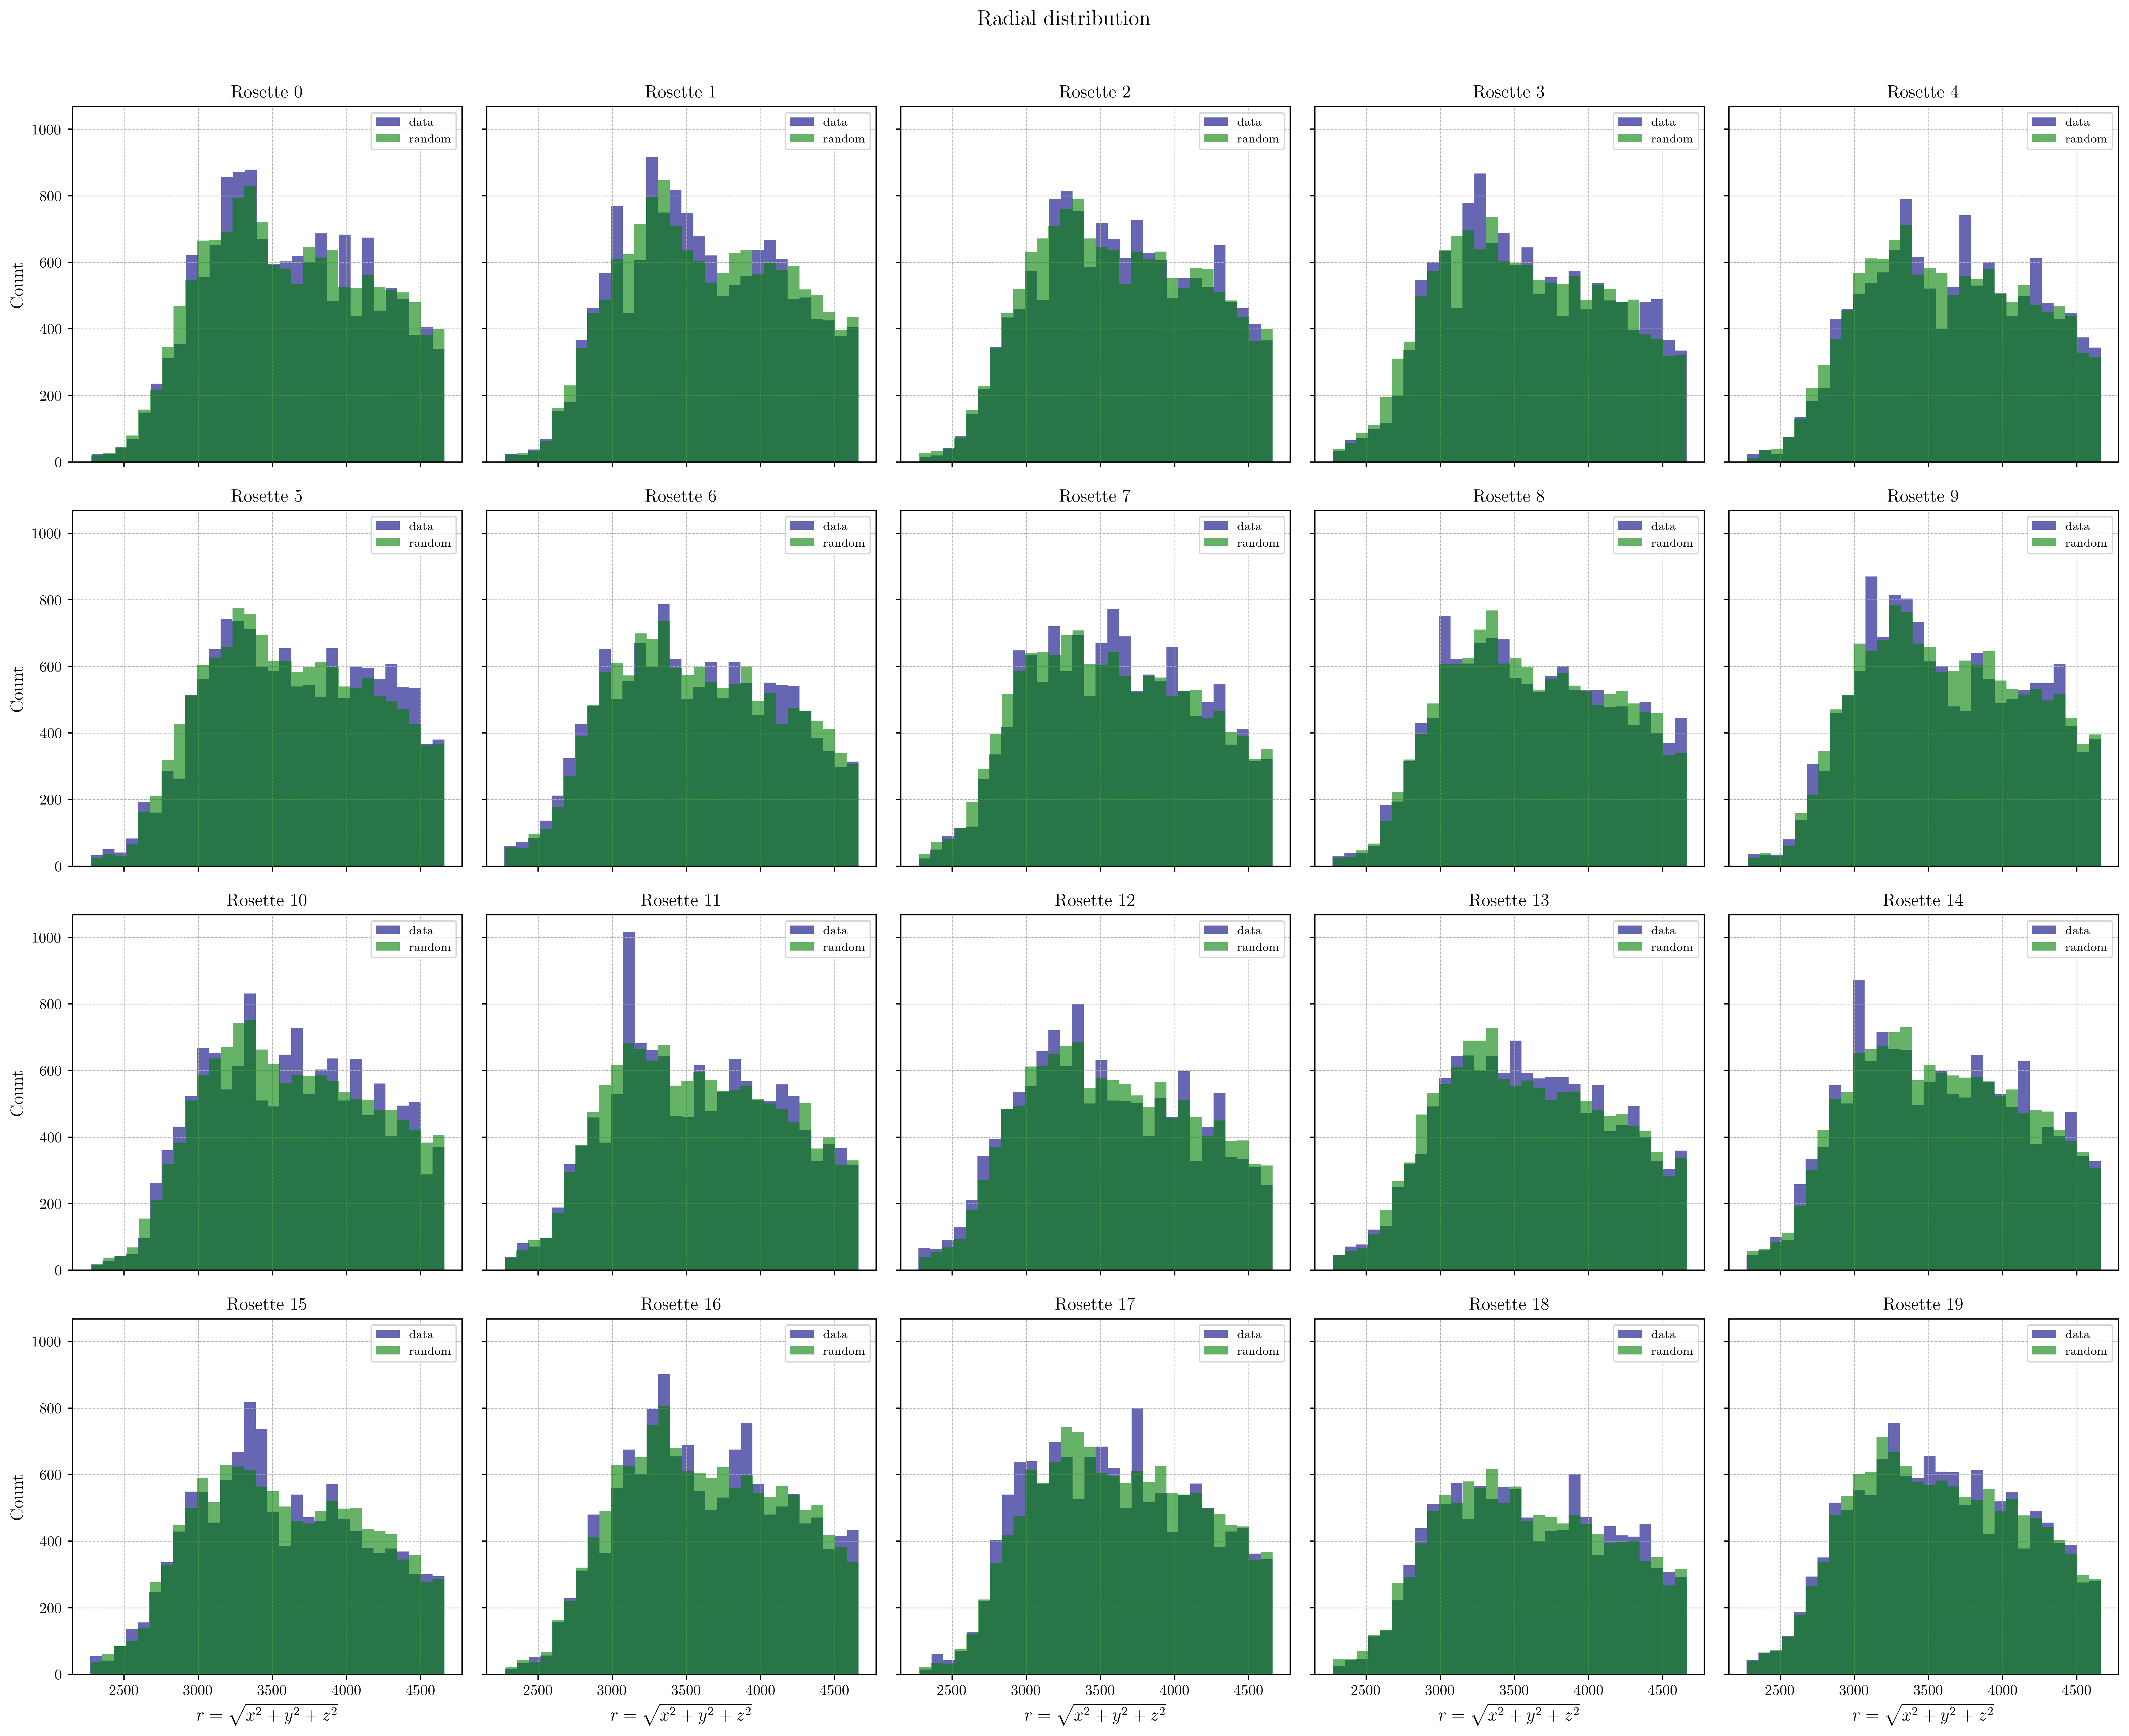

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharex=True, sharey=True)
axes = axes.flatten()

for r_id in range(20):
    data = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_data.ecsv',
                       comment='#', sep=r'\s+', engine='python')
    rand = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_rand.ecsv',
                       comment='#', sep=r'\s+', engine='python')

    coords = data[['X','Y','Z']].values
    data['d'] = np.linalg.norm(coords, axis=1)

    coords_rand = rand[['X','Y','Z']].values
    rand['d']  = np.linalg.norm(coords_rand, axis=1)

    ax = axes[r_id]
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.hist(data['d'], bins=30, alpha=0.6, label='data', color='navy', zorder=1)
    ax.hist(rand['d'], bins=30, alpha=0.6, label='random', color='green', zorder=2)

    ax.set_title(f'Rosette {r_id}', size=12)
    ax.legend(fontsize=8)
    if r_id > 14:
        ax.set_xlabel(r'$r = \sqrt{x^2 + y^2 + z^2}$')
    if r_id in [0, 5, 10, 15]:
        ax.set_ylabel('Count')

fig.suptitle('Radial distribution', y=1.01)
plt.tight_layout()
plt.show()

### PCA

In [58]:
types = ['void', 'sheet', 'filament', 'knot']
width_pc3 = 20
plt.style.use('dark_background')

In [59]:
for r_id in range(20):

    data = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_data.ecsv',
                       comment='#', sep=r'\s+', engine='python')
    rand = pd.read_csv(f'{base_url}ELG_{r_id}_clustering_rand.ecsv',
                       comment='#', sep=r'\s+', engine='python')
    indices = np.random.choice(len(rand), size=len(data), replace=False)
    subset_rand = rand.iloc[indices].reset_index(drop=True)
    df_typed, _, tri3d, is_real = astra(data, subset_rand)

    pca3 = PCA(n_components=3)
    coords3 = pca3.fit_transform(df_typed[['X','Y','Z']].values)
    df_typed['PC1'], df_typed['PC2'], df_typed['PC3'] = coords3.T

    fig_f, axes_f = plt.subplots(4, 1, figsize=(15, 8), sharex=True, sharey=True)
    for ax, tp in zip(axes_f, types):
        sel = df_typed['TYPE'] == tp
        ax.scatter(df_typed.loc[sel & ~is_real, 'PC1'],
                   df_typed.loc[sel & ~is_real, 'PC2'],
                   s=0.03, label='random', zorder=5)
        ax.scatter(df_typed.loc[sel &  is_real, 'PC1'],
                   df_typed.loc[sel &  is_real, 'PC2'],
                   s=0.03, label='real',   zorder=10)
        ax.set_title(tp.capitalize())
        ax.set_ylabel('PC2')
        ax.legend(markerscale=15, loc='upper left')

    axes_f[-1].set_xlabel('PC1')
    fig_f.suptitle(f'Rosette {r_id}')
    fig_f.tight_layout(rect=[0, 0, 1, 0.95])
    fig_f.savefig(f'./plots/types/full/rosette_{r_id}.png', dpi=360)
    plt.close(fig_f)

    pc3_med = df_typed['PC3'].median()
    pc3_min, pc3_max = pc3_med - width_pc3, pc3_med + width_pc3
    mask_slice = (df_typed['PC3'] > pc3_min) & (df_typed['PC3'] < pc3_max)
    df_slice = df_typed[mask_slice].copy()
    is_real_slice = is_real[mask_slice]

    fig_s, axes_s = plt.subplots(4, 1, figsize=(15, 8), sharex=True, sharey=True)
    for ax, tp in zip(axes_s, types):
        sel = df_slice['TYPE'] == tp
        ax.scatter(df_slice.loc[sel & ~is_real_slice, 'PC1'],
                   df_slice.loc[sel & ~is_real_slice, 'PC2'],
                   s=0.03, label='random', zorder=5)
        ax.scatter(df_slice.loc[sel &  is_real_slice, 'PC1'],
                   df_slice.loc[sel &  is_real_slice, 'PC2'],
                   s=0.03, label='real',   zorder=10)
        ax.set_title(tp.capitalize())
        ax.set_ylabel('PC2')
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.legend(markerscale=15, loc='upper left')

    axes_s[-1].set_xlabel('PC1')
    fig_s.subplots_adjust(top=0.88)
    plt.suptitle(f'Rosette {r_id}\n{pc3_min:.1f}'+' $< PC3 <$ '+f'{pc3_max:.1f}')
    fig_s.tight_layout(rect=[0, 0, 1, 0.92])
    fig_s.savefig(f'./plots/types/filtered/rosette_{r_id}.png', dpi=360)
    plt.close(fig_s)